# Pricing Options: From Black–Scholes to Monte Carlo
## Step 5 — Monte Carlo Pricing of a European Option

**Target audience:** second-year undergraduate students  
**Goal of this notebook:** understand how Monte Carlo simulation can be used to price a European option and how the numerical estimate connects to the Black–Scholes formula.

---

## Learning objectives

At the end of this notebook, the student should be able to:

- explain the idea of Monte Carlo pricing,
- simulate terminal stock prices under the Black–Scholes model,
- compute the payoff of a European call and a European put,
- discount simulated payoffs to estimate the option price,
- compare the Monte Carlo estimate with the Black–Scholes formula,
- understand why the Monte Carlo estimator is random,
- explain why increasing the number of simulations improves accuracy.


## 1. Why do we need Monte Carlo methods?

For a European call and put under Black–Scholes, we already have a closed-form formula.
So why use simulation at all?

Because many derivatives are much more complicated:

- path-dependent options,
- basket options,
- barrier options,
- options in more advanced models.

For such products, a closed-form formula may not exist.
In those situations, Monte Carlo simulation becomes a very powerful numerical tool.

The European option is therefore the perfect first example:

- simple enough to understand,
- but rich enough to illustrate the full simulation idea.


## 2. General principle of Monte Carlo pricing

Under the risk-neutral Black–Scholes model, the price of a European option today is the discounted expected value of its payoff.

For a European call,

$$
C_0 = e^{-rT}\,\mathbb{E}\big[(S_T-K)^+\big].
$$

For a European put,

$$
P_0 = e^{-rT}\,\mathbb{E}\big[(K-S_T)^+\big].
$$

The Monte Carlo idea is simple:

1. simulate many possible values of $S_T$,
2. compute the payoff for each simulated path,
3. average the payoffs,
4. discount the average back to time 0.

This gives a numerical approximation of the option price.


## 3. Risk-neutral terminal stock price

Under the Black–Scholes risk-neutral model, the terminal stock price satisfies

$$
S_T = S_0 \exp\left(\left(r - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right),
$$

where

$$
Z \sim \mathcal{N}(0,1).
$$

This means that to simulate $S_T$, we only need to generate standard normal random variables.

Notice the important point:

- the drift is **$r$**, not $\mu$.

This is because pricing is done under the **risk-neutral measure**.


## 4. Core Python tools

The next cell defines:

- the standard normal cumulative distribution function,
- the Black–Scholes formulas for a European call and put,
- the Monte Carlo estimators for a European call and put.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

# Standard normal cumulative distribution function

def Phi(x):
    return 0.5 * (1.0 + erf(x / math.sqrt(2.0)))


def bs_call_price(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S0 * Phi(d1) - K * exp(-r * T) * Phi(d2)


def bs_put_price(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return K * exp(-r * T) * Phi(-d2) - S0 * Phi(-d1)


def mc_call_price(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)


def mc_put_price(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(K - ST, 0)
    return np.exp(-r * T) * np.mean(payoffs)


## 5. First numerical comparison: Monte Carlo vs. Black–Scholes

We start with a standard set of parameters:

- $S_0 = 100$
- $K = 100$
- $T = 1$
- $r = 5\%$
- $\sigma = 20\%$
- $N = 100{,}000$ simulations

We then compare the Monte Carlo estimates with the exact Black–Scholes prices.


In [2]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20
N = 100_000

mc_call = mc_call_price(S0, K, T, r, sigma, N, seed=123)
mc_put = mc_put_price(S0, K, T, r, sigma, N, seed=123)
bs_call = bs_call_price(S0, K, T, r, sigma)
bs_put = bs_put_price(S0, K, T, r, sigma)

print(f"Monte Carlo call price : {mc_call:.4f}")
print(f"Black–Scholes call    : {bs_call:.4f}")
print()
print(f"Monte Carlo put price : {mc_put:.4f}")
print(f"Black–Scholes put     : {bs_put:.4f}")


Monte Carlo call price : 10.4715
Black–Scholes call    : 10.4506

Monte Carlo put price : 5.5694
Black–Scholes put     : 5.5735


### Interpretation

The Monte Carlo estimates are close to the Black–Scholes prices, but not exactly equal.
This is normal: Monte Carlo uses a finite number of simulations, so the estimate contains **statistical error**.


## 6. What exactly are we simulating?

To make the Monte Carlo method more concrete, we now visualize:

1. the simulated terminal stock prices $S_T$,
2. the distribution of call payoffs,
3. the distribution of put payoffs,
4. the relation between $S_T$ and the call payoff.


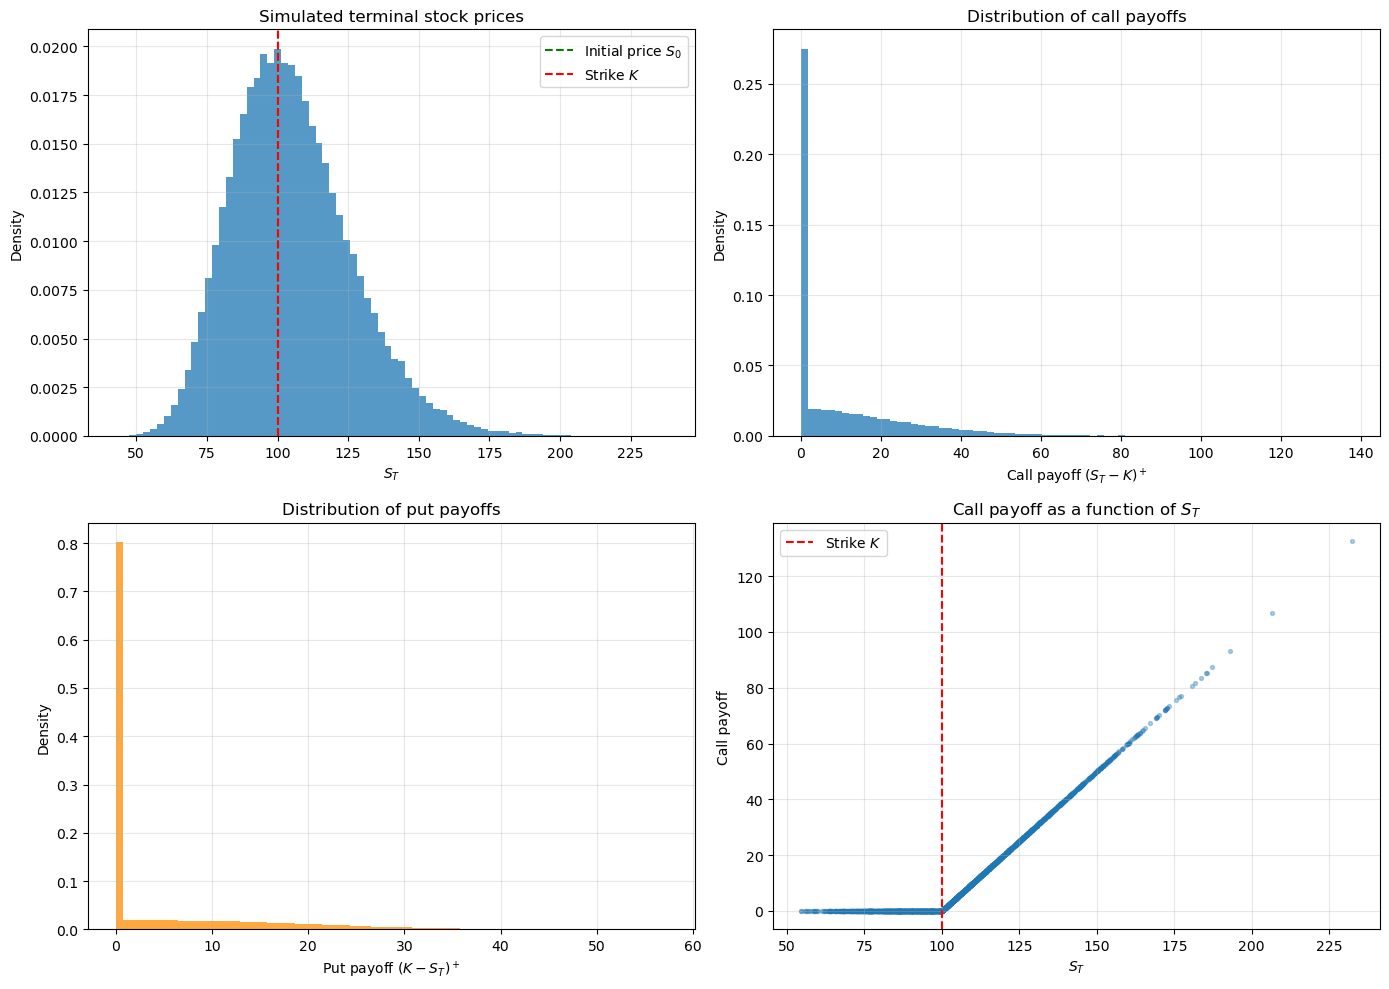

In [3]:
# Reuse one common simulation sample for all visualizations
np.random.seed(123)
Z = np.random.randn(N)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
call_payoffs = np.maximum(ST - K, 0)
put_payoffs = np.maximum(K - ST, 0)
discounted_call_payoffs = np.exp(-r * T) * call_payoffs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Histogram of terminal stock prices
axes[0, 0].hist(ST, bins=80, density=True, alpha=0.75)
axes[0, 0].axvline(S0, color='green', linestyle='--', label='Initial price $S_0$')
axes[0, 0].axvline(K, color='red', linestyle='--', label='Strike $K$')
axes[0, 0].set_title('Simulated terminal stock prices')
axes[0, 0].set_xlabel('$S_T$')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# (2) Histogram of call payoffs
axes[0, 1].hist(call_payoffs, bins=80, density=True, alpha=0.75, color='tab:blue')
axes[0, 1].set_title('Distribution of call payoffs')
axes[0, 1].set_xlabel('Call payoff $(S_T-K)^+$')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# (3) Histogram of put payoffs
axes[1, 0].hist(put_payoffs, bins=80, density=True, alpha=0.75, color='darkorange')
axes[1, 0].set_title('Distribution of put payoffs')
axes[1, 0].set_xlabel('Put payoff $(K-S_T)^+$')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

# (4) Scatter plot: terminal stock price vs call payoff
sample_idx = np.random.choice(len(ST), size=3000, replace=False)
axes[1, 1].scatter(ST[sample_idx], call_payoffs[sample_idx], s=8, alpha=0.35)
axes[1, 1].axvline(K, color='red', linestyle='--', label='Strike $K$')
axes[1, 1].set_title('Call payoff as a function of $S_T$')
axes[1, 1].set_xlabel('$S_T$')
axes[1, 1].set_ylabel('Call payoff')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### What should we observe?

- The simulated terminal stock prices are **right-skewed**, which is consistent with the lognormal model.
- The **call payoff** has many zeros because the option expires worthless when $S_T < K$.
- The **put payoff** has many zeros when $S_T > K$.
- The scatter plot shows the nonlinear structure of the call payoff: below the strike the payoff is zero, above the strike it increases linearly.


## 7. Why is the Monte Carlo estimate random?

Each time we run the simulation, we generate new random values.
Therefore, the estimated option price changes slightly from one run to another.

This means that the Monte Carlo estimator is itself a **random variable**.

The next cell repeats the same pricing experiment several times.


In [4]:
N_small = 20_000
estimates = []
for seed in range(10):
    estimates.append(mc_call_price(S0, K, T, r, sigma, N_small, seed=seed))

print("Ten Monte Carlo estimates of the same call price:")
for i, est in enumerate(estimates, start=1):
    print(f"Run {i:2d}: {est:.4f}")


Ten Monte Carlo estimates of the same call price:
Run  1: 10.2945
Run  2: 10.5757
Run  3: 10.4785
Run  4: 10.2576
Run  5: 10.4003
Run  6: 10.5164
Run  7: 10.3819
Run  8: 10.2294
Run  9: 10.4441
Run 10: 10.4135


### Interpretation

Even though all runs are pricing the **same option**, the numerical estimates are not identical.
This variability is a normal feature of Monte Carlo simulation.


## 8. Visualizing convergence of the Monte Carlo estimator

A very instructive way to understand Monte Carlo is to track the **running average** of discounted payoffs.

If the method works, the running estimate should gradually stabilize near the exact Black–Scholes price.


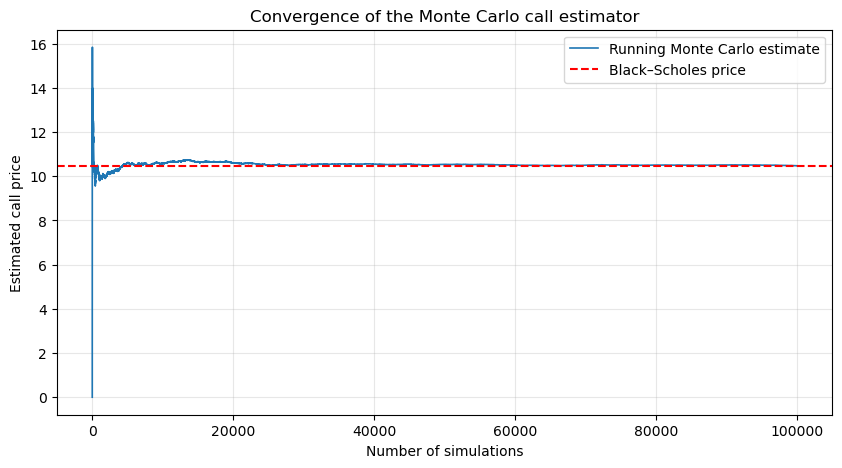

In [5]:
running_estimate = np.cumsum(discounted_call_payoffs) / np.arange(1, N + 1)

plt.figure(figsize=(10, 5))
plt.plot(running_estimate, lw=1.2, label='Running Monte Carlo estimate')
plt.axhline(bs_call, color='red', linestyle='--', label='Black–Scholes price')
plt.title('Convergence of the Monte Carlo call estimator')
plt.xlabel('Number of simulations')
plt.ylabel('Estimated call price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

At the beginning, the estimate fluctuates significantly because it is based on only a few simulations.
As the number of simulations grows, the estimator becomes more stable and approaches the Black–Scholes benchmark.


## 9. Convergence as the sample size increases

We can also compute the Monte Carlo price for several values of $N$ and compare each estimate to the exact price.


In [6]:
sample_sizes = [100, 300, 1000, 3000, 10_000, 30_000, 100_000, 300_000]
mc_estimates = [mc_call_price(S0, K, T, r, sigma, n, seed=42) for n in sample_sizes]
bs_exact = bs_call_price(S0, K, T, r, sigma)

for n, est in zip(sample_sizes, mc_estimates):
    print(f"N = {n:6d}   Monte Carlo estimate = {est:.6f}")

print(f"\nBlack–Scholes exact price = {bs_exact:.6f}")


N =    100   Monte Carlo estimate = 8.159991
N =    300   Monte Carlo estimate = 10.221948
N =   1000   Monte Carlo estimate = 10.516569
N =   3000   Monte Carlo estimate = 10.719031
N =  10000   Monte Carlo estimate = 10.450170
N =  30000   Monte Carlo estimate = 10.432731
N = 100000   Monte Carlo estimate = 10.473892
N = 300000   Monte Carlo estimate = 10.451689

Black–Scholes exact price = 10.450584


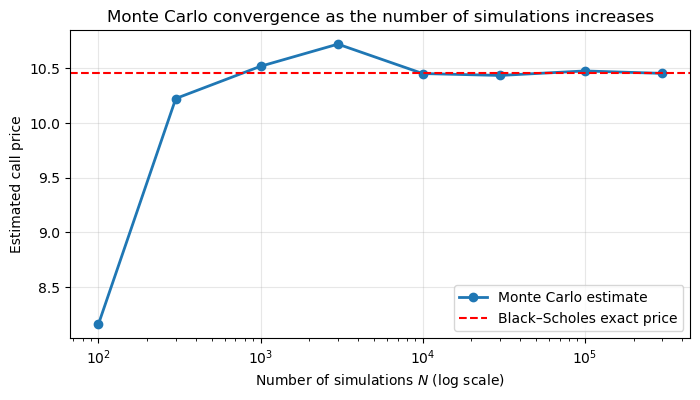

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, mc_estimates, marker='o', lw=2, label='Monte Carlo estimate')
plt.axhline(bs_exact, color='red', linestyle='--', label='Black–Scholes exact price')
plt.xscale('log')
plt.title('Monte Carlo convergence as the number of simulations increases')
plt.xlabel('Number of simulations $N$ (log scale)')
plt.ylabel('Estimated call price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

As $N$ increases, the Monte Carlo estimate becomes more reliable.
This is the basic convergence phenomenon behind simulation-based pricing.


## 10. Error and the rate $1/\sqrt{N}$

A fundamental fact about Monte Carlo is that its statistical error typically decreases like

$$
\frac{1}{\sqrt{N}}.
$$

This is both powerful and costly.
It means that:

- increasing $N$ improves accuracy,
- but to divide the error by 2, we need about **4 times more simulations**.


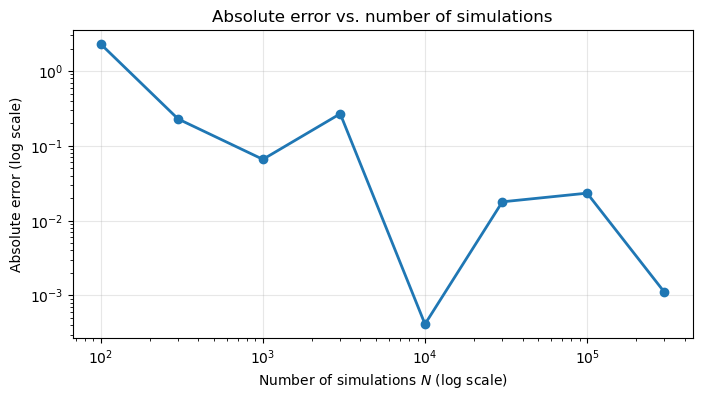

In [8]:
errors = [abs(est - bs_exact) for est in mc_estimates]

plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, errors, marker='o', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Absolute error vs. number of simulations')
plt.xlabel('Number of simulations $N$ (log scale)')
plt.ylabel('Absolute error (log scale)')
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

On a log-log scale, the error generally decreases as $N$ increases.
The theoretical convergence rate is roughly proportional to $N^{-1/2}$.


## 11. Option prices as functions of the strike

It is often useful to see that an option price is not a single number, but a function of the contract parameters.

The next graph shows how the Black–Scholes call and put prices vary with the strike $K$.


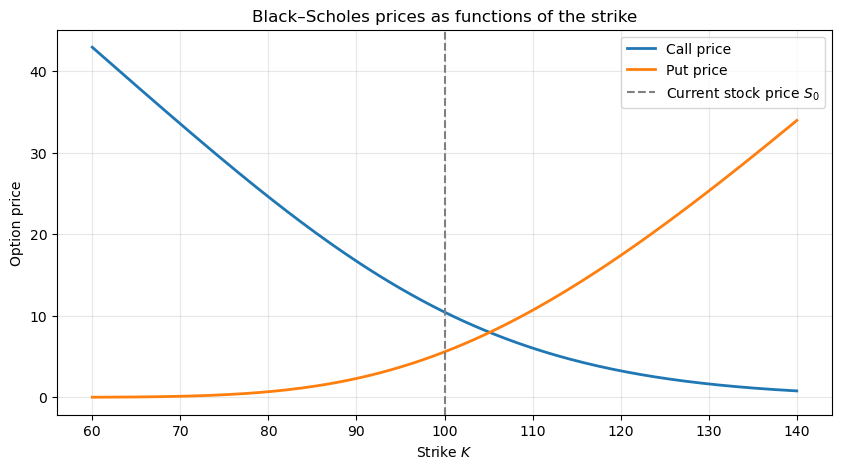

In [9]:
K_values = np.linspace(60, 140, 200)
call_prices_vs_K = [bs_call_price(S0, k, T, r, sigma) for k in K_values]
put_prices_vs_K = [bs_put_price(S0, k, T, r, sigma) for k in K_values]

plt.figure(figsize=(10, 5))
plt.plot(K_values, call_prices_vs_K, label='Call price', lw=2)
plt.plot(K_values, put_prices_vs_K, label='Put price', lw=2)
plt.axvline(S0, color='gray', linestyle='--', label='Current stock price $S_0$')
plt.title('Black–Scholes prices as functions of the strike')
plt.xlabel('Strike $K$')
plt.ylabel('Option price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

- As the strike increases, the **call price decreases**.
- As the strike increases, the **put price increases**.

This is perfectly consistent with financial intuition.


## 12. Intrinsic value and time value

Before maturity, the Black–Scholes price is usually **larger** than the intrinsic value of the option.
The difference is called the **time value**.

We now compare the Black–Scholes price with intrinsic value for both the call and the put.


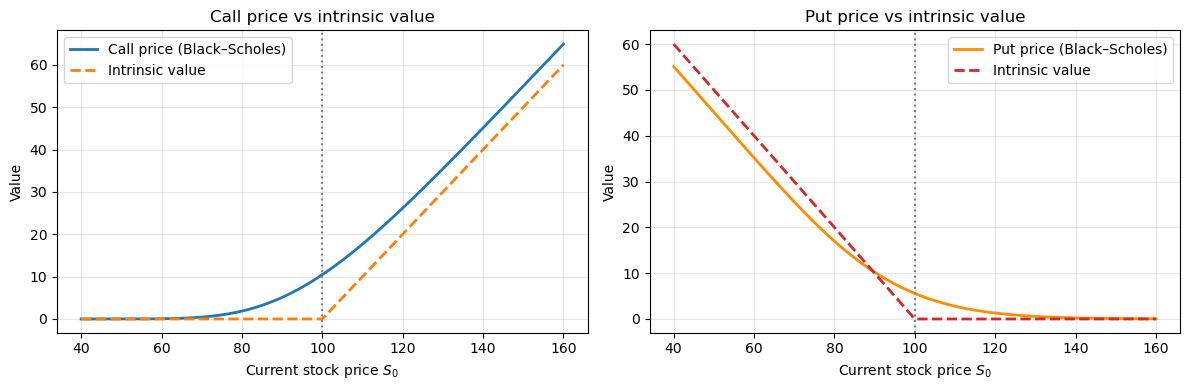

In [10]:
S_grid = np.linspace(40, 160, 300)

call_bs_curve = [bs_call_price(S, K, T, r, sigma) for S in S_grid]
put_bs_curve = [bs_put_price(S, K, T, r, sigma) for S in S_grid]

call_intrinsic = np.maximum(S_grid - K, 0)
put_intrinsic = np.maximum(K - S_grid, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(S_grid, call_bs_curve, lw=2, label='Call price (Black–Scholes)')
axes[0].plot(S_grid, call_intrinsic, linestyle='--', lw=2, label='Intrinsic value')
axes[0].axvline(K, color='gray', linestyle=':')
axes[0].set_title('Call price vs intrinsic value')
axes[0].set_xlabel('Current stock price $S_0$')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(S_grid, put_bs_curve, lw=2, label='Put price (Black–Scholes)', color='darkorange')
axes[1].plot(S_grid, put_intrinsic, linestyle='--', lw=2, label='Intrinsic value', color='tab:red')
axes[1].axvline(K, color='gray', linestyle=':')
axes[1].set_title('Put price vs intrinsic value')
axes[1].set_xlabel('Current stock price $S_0$')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation

The Black–Scholes price is above intrinsic value because the option still has time to become more favorable before maturity.
That extra value is the **time value** of the option.


## 13. A compact reusable Monte Carlo function

It is often convenient to build a compact function that returns both the call and put prices at the same time.


In [11]:
def mc_call_put_prices(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    call_payoffs = np.maximum(ST - K, 0)
    put_payoffs = np.maximum(K - ST, 0)
    call_price = np.exp(-r * T) * np.mean(call_payoffs)
    put_price = np.exp(-r * T) * np.mean(put_payoffs)
    return call_price, put_price

call_mc, put_mc = mc_call_put_prices(100, 100, 1.0, 0.05, 0.20, 200_000, seed=7)
print(f"Call MC price: {call_mc:.4f}")
print(f"Put MC price : {put_mc:.4f}")


Call MC price: 10.4271
Put MC price : 5.5639


## 14. Comparison table: exact formula vs Monte Carlo

The next cell summarizes the comparison between the exact Black–Scholes prices and the Monte Carlo approximations.


In [12]:
N_compare = 200_000
mc_call2, mc_put2 = mc_call_put_prices(S0, K, T, r, sigma, N_compare, seed=99)
bs_call2 = bs_call_price(S0, K, T, r, sigma)
bs_put2 = bs_put_price(S0, K, T, r, sigma)

print("European option pricing comparison")
print("-" * 40)
print(f"Black–Scholes call : {bs_call2:.6f}")
print(f"Monte Carlo call   : {mc_call2:.6f}")
print(f"Absolute error     : {abs(mc_call2 - bs_call2):.6f}")
print()
print(f"Black–Scholes put  : {bs_put2:.6f}")
print(f"Monte Carlo put    : {mc_put2:.6f}")
print(f"Absolute error     : {abs(mc_put2 - bs_put2):.6f}")


European option pricing comparison
----------------------------------------
Black–Scholes call : 10.450584
Monte Carlo call   : 10.446345
Absolute error     : 0.004238

Black–Scholes put  : 5.573526
Monte Carlo put    : 5.570286
Absolute error     : 0.003240


## 15. Advantages and limitations of Monte Carlo

### Advantages

- conceptually simple,
- flexible,
- works well in high-dimensional settings,
- adapts to many exotic payoffs.

### Limitations

- slow convergence,
- statistical noise,
- can require many simulations for high precision,
- often benefits from variance reduction techniques.

In later steps, we will improve the basic Monte Carlo estimator using statistical tools.


## 16. Summary

### Main ideas to remember

- Under the risk-neutral Black–Scholes model,
  $$S_T = S_0 \exp\left(\left(r-\frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}Z\right).$$
- A European call price is the discounted expected payoff:
  $$C_0 = e^{-rT}\,\mathbb{E}[(S_T-K)^+].$$
- Monte Carlo approximates this expectation by simulation.
- The estimator is random because it depends on random samples.
- As the number of simulations increases, the estimator converges toward the true price.
- The typical error decreases like $1/\sqrt{N}$.
- The Black–Scholes benchmark helps us verify that the Monte Carlo method is working correctly.


## 17. Exercises for the student

1. Why do we use the risk-free rate $r$ in the simulation of $S_T$?
2. Why is the Monte Carlo estimate random?
3. What are the four main steps of a Monte Carlo pricing algorithm?
4. Why does increasing the number of simulations improve the estimate?
5. If you want to divide the Monte Carlo error by 2, roughly how many more simulations do you need?
6. Why is Monte Carlo especially useful for complex derivatives?
7. Why is the Black–Scholes price usually larger than intrinsic value before maturity?


## 18. What comes next?

Now that we have the basic Monte Carlo estimator, the next natural step is statistical analysis.

### **Notebook 6 — Why Monte Carlo Works: Law of Large Numbers, Central Limit Theorem, and Confidence Intervals**

In the next notebook, we can explain:

- why the Monte Carlo estimator converges,
- how to quantify its error,
- how to build a confidence interval,
- and why the accuracy improves like $1/\sqrt{N}$.
